# Customer Churn Prediction

This notebook demonstrates a complete end-to-end machine learning pipeline for predicting customer churn. We will use a synthetic dataset (`customer_churn_data.csv`) that includes customer demographics, account information, and usage metrics.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('customer_churn_data.csv')
df.head()

,CustomerID,Age,Gender,Tenure_Months,Contract_Type,Internet_Service,Monthly_Charges,Total_Charges,Support_Calls,Payment_Method,Churn
0,CUST_0001,56,Male,48,Month-to-month,Fiber optic,88.94,4269.12,5,Credit card,0
1,CUST_0002,69,Female,42,One year,Fiber optic,79.83,3352.86,8,Credit card,0
2,CUST_0003,46,Female,27,One year,DSL,25.30,683.10,3,Credit card,0
3,CUST_0004,32,Female,52,Month-to-month,No,27.84,1447.68,2,Bank transfer,1
4,CUST_0005,60,Female,42,Two year,Fiber optic,22.08,927.36,8,Electronic check,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        5000 non-null   object 
 1   Age               5000 non-null   int64  
 2   Gender            5000 non-null   object 
 3   Tenure_Months     5000 non-null   int64  
 4   Contract_Type     5000 non-null   object 
 5   Internet_Service  5000 non-null   object 
 6   Monthly_Charges   5000 non-null   float64
 7   Total_Charges     4950 non-null   float64
 8   Support_Calls     5000 non-null   int64  
 9   Payment_Method    5000 non-null   object 
 10  Churn             5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


In [4]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Support_Calls,Churn
count,5000.000000,5000.00000,5000.00000,4950.000000,5000.000000,5000.000000
mean,48.805600,36.25240,70.96236,2561.000838,4.605600,0.312400
std,17.906991,20.57282,28.82412,1869.536638,2.852451,0.463518
min,18.000000,1.00000,20.00000,23.670000,0.000000,0.000000
25%,34.000000,18.00000,46.08000,1044.340000,2.000000,0.000000
50%,49.000000,36.00000,71.41500,2152.380000,5.000000,0.000000
75%,64.000000,54.00000,95.89250,3763.772500,7.000000,1.000000
max,79.000000,71.00000,119.99000,8497.280000,9.000000,1.000000


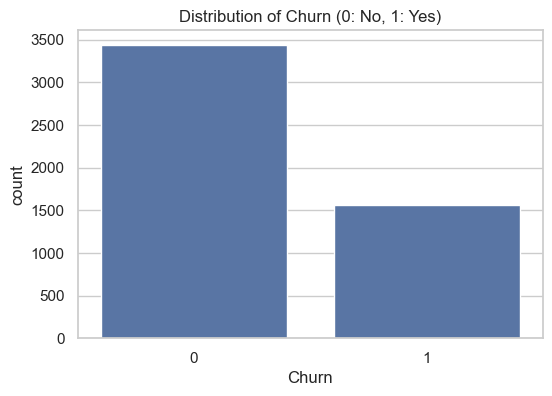

In [5]:
# Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn (0: No, 1: Yes)')
plt.show()

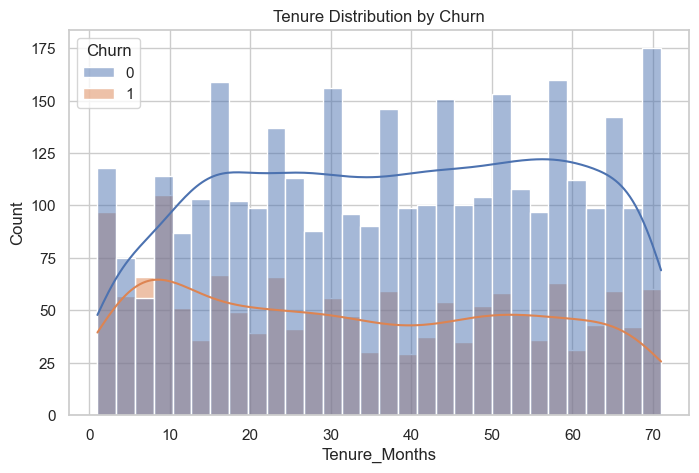

In [6]:
# Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Tenure_Months', hue='Churn', kde=True, bins=30)
plt.title('Tenure Distribution by Churn')
plt.show()

## 4. Data Preprocessing

In [7]:
# Handle missing values (if any)
print("Missing values before filling:\n", df.isnull().sum())
df['Total_Charges'] = df['Total_Charges'].fillna(df['Total_Charges'].median())

# Drop CustomerID as it's not useful for prediction
df = df.drop('CustomerID', axis=1)

Missing values before filling:
 CustomerID           0
Age                  0
Gender               0
Tenure_Months        0
Contract_Type        0
Internet_Service     0
Monthly_Charges      0
Total_Charges       50
Support_Calls        0
Payment_Method       0
Churn                0
dtype: int64


In [8]:
# Encode categorical variables
categorical_cols = ['Gender', 'Contract_Type', 'Internet_Service', 'Payment_Method']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    
df.head()

,Age,Gender,Tenure_Months,Contract_Type,Internet_Service,Monthly_Charges,Total_Charges,Support_Calls,Payment_Method,Churn
0,56,1,48,0,1,88.94,4269.12,5,1,0
1,69,0,42,1,1,79.83,3352.86,8,1,0
2,46,0,27,1,0,25.30,683.10,3,1,0
3,32,0,52,0,2,27.84,1447.68,2,0,1
4,60,0,42,2,1,22.08,927.36,8,2,0


## 5. Model Training

In [9]:
# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4000, 9)
Testing data shape: (1000, 9)


In [10]:
# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Model Evaluation

In [11]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6600

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.87      0.78       672
           1       0.46      0.22      0.30       328

    accuracy                           0.66      1000
   macro avg       0.58      0.55      0.54      1000
weighted avg       0.62      0.66      0.62      1000



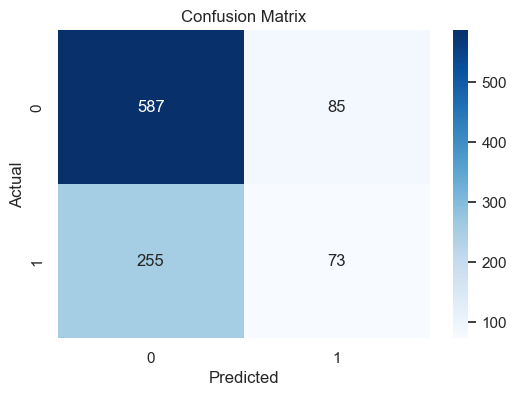

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. Feature Importance

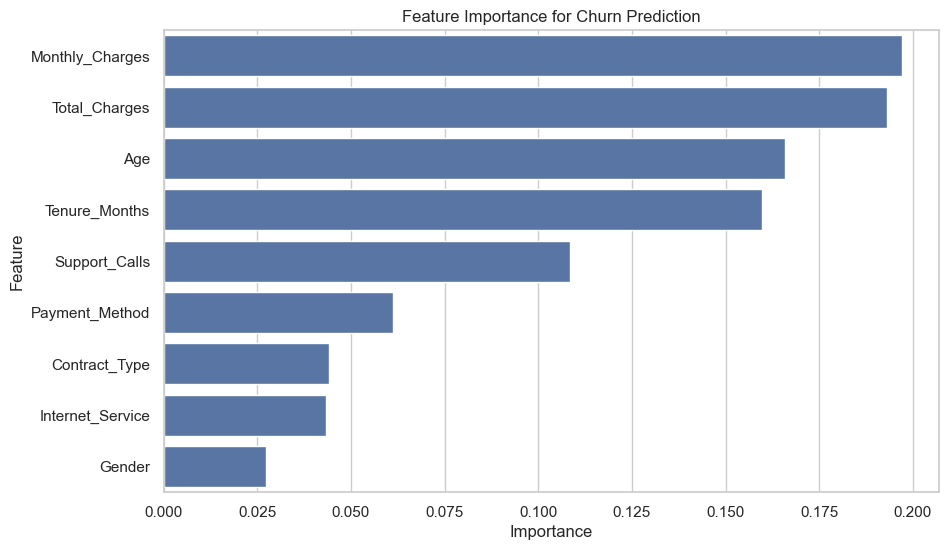

In [13]:
# Plot feature importance
feature_importance = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Churn Prediction')
plt.show()